In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import json
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

df = pd.read_csv('S12-hw-dataset.csv')
print("Размер датасета:", df.shape)
print("Колонки:", df.columns.tolist())

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("\nПропуски по колонкам:\n", df.isnull().sum())

Using device: cpu
Размер датасета: (4320, 2)
Колонки: ['date', 'target']

Пропуски по колонкам:
 date      0
target    0
dtype: int64


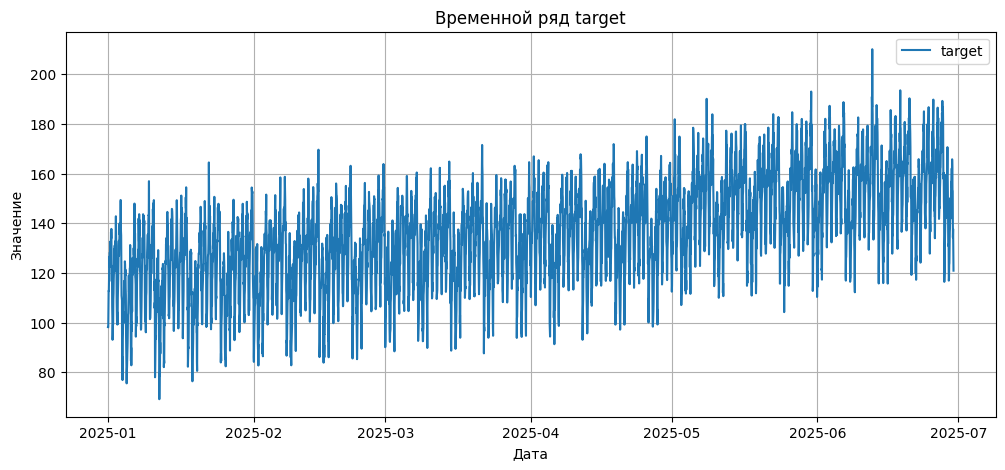


Описательная статистика target:
 count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


In [46]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['target'], label='target')
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.show()

print("\nОписательная статистика target:\n", df['target'].describe())

Обнаружено 2 выбросов по IQR


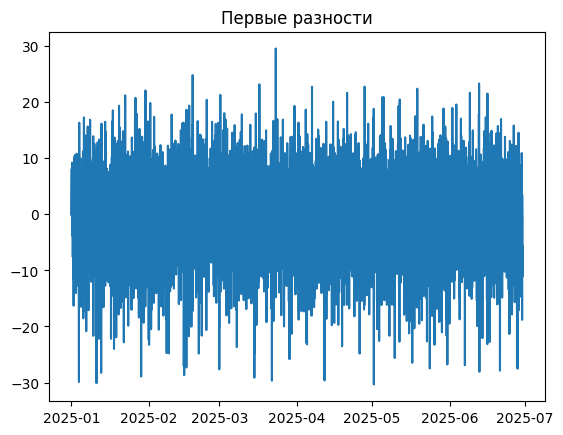

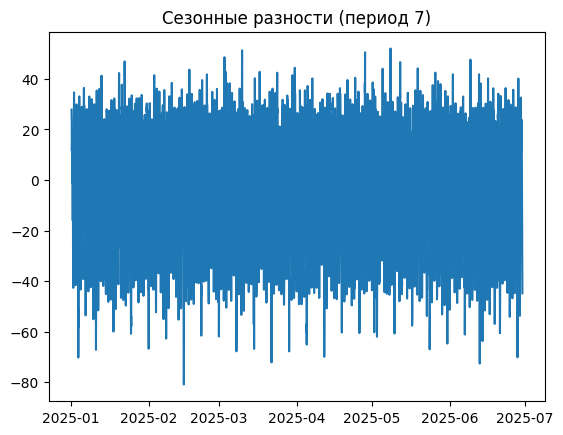

In [47]:
Q1 = df['target'].quantile(0.25)
Q3 = df['target'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['target'] < lower_bound) | (df['target'] > upper_bound)]
print(f"Обнаружено {len(outliers)} выбросов по IQR")

# Первые разности
df['diff'] = df['target'].diff()
plt.plot(df['date'], df['diff'])
plt.title('Первые разности')
plt.show()

# Сезонные разности (период 7)
df['seasonal_diff'] = df['target'].diff(7)
plt.plot(df['date'], df['seasonal_diff'])
plt.title('Сезонные разности (период 7)')
plt.show()

Ряд имеет возрастающий тренд, присутствует 2 выброса.Ряд стационарен, нет сезонности.

Train: 2025-01-01 00:00:00 -> 2025-05-06 23:00:00 (n=3024)
Val:   2025-05-07 00:00:00 -> 2025-06-02 23:00:00 (n=648)
Test:  2025-06-03 00:00:00 -> 2025-06-29 23:00:00 (n=648)


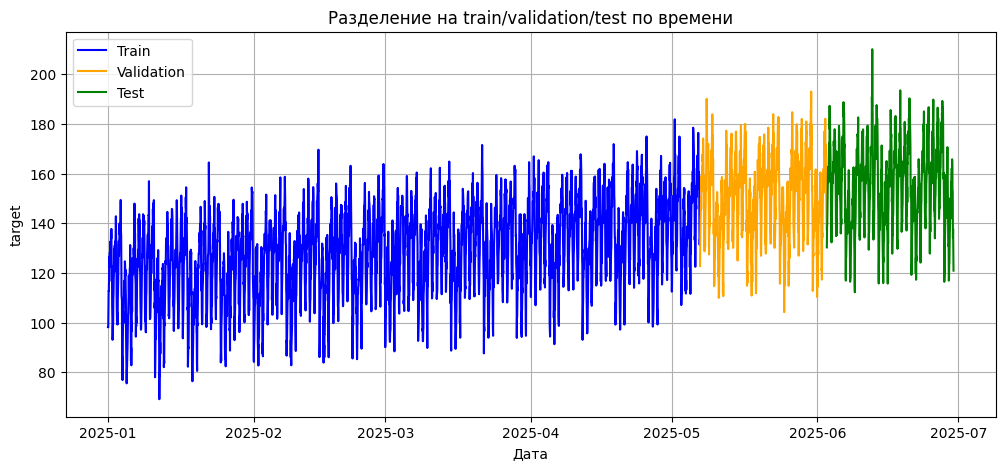

In [48]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print(f"Train: {train['date'].min()} -> {train['date'].max()} (n={len(train)})")
print(f"Val:   {val['date'].min()} -> {val['date'].max()} (n={len(val)})")
print(f"Test:  {test['date'].min()} -> {test['date'].max()} (n={len(test)})")

plt.figure(figsize=(12, 5))
plt.plot(train['date'], train['target'], label='Train', color='blue')
plt.plot(val['date'], val['target'], label='Validation', color='orange')
plt.plot(test['date'], test['target'], label='Test', color='green')
plt.title('Разделение на train/validation/test по времени')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()

In [49]:
def create_features(df, window=7):
    df = df.copy()
    df = df.sort_values('date')
    # Лаговые признаки
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    # Rolling статистики
    df['rolling_mean_7'] = df['target'].rolling(window=7).mean()
    df['rolling_std_7'] = df['target'].rolling(window=7).std()
    # Календарные признаки
    df['dayofweek'] = df['date'].dt.dayofweek
    # Удаляем строки с NaN (появились из-за shift/rolling)
    df = df.dropna().reset_index(drop=True)
    return df

train_feat = create_features(train)
val_feat = create_features(val)
test_feat = create_features(test)

X_train = train_feat[['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek']]
y_train = train_feat['target']

X_val = val_feat[['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek']]
y_val = val_feat['target']

X_test = test_feat[['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek']]
y_test = test_feat['target']

In [50]:
# Масштабирование признаков (обучаем только на train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Применение random split к временным рядам недопустимо, поскольку в задачах прогнозирования временных рядов возникает риск утечки данных: модель может получить доступ к данным из будущего относительно момента, для которого делается предсказание.
Ключевые риски, которые учли:
Разбиение выбрки - перемешивание строк нарушает временную последовательность, из-за чего алгоритм может неявно использовать будущие значения при обучении. Вместо этого мы применили строгое temporal split (train -> validation -> test) без какой-либо перемешивания.
Генерация признаков - лаги (shift) и скользящие статистики (rolling) рассчитывались исключительно на основе предшествующих наблюдений (например, shift(1) или rolling(window=7).mean()), что исключает возможность «заглянуть вперёд».
Масштабирование - параметры StandardScaler были вычислены только на обучающей подвыборке, после чего фиксированно применены к валидационной и тестовой частям. Это предотвращает утечку информации о распределении.
Оконное представление для GRU - последовательности конструируются таким образом, что целевое значение всегда следует строго после последнего элемента входной последовательности. Это гарантирует, что модель не имеет доступа к будущей информации в момент предсказания.

In [51]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, target, window_size):
        self.data = data
        self.target = target
        self.window_size = window_size
        
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        x = self.data[idx:idx+self.window_size]
        y = self.target[idx+self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Параметры окна
window_size = 10

# Для GRU используем только target (или можно добавить признаки)
# Масштабируем target
target_scaler = StandardScaler()
target_train = train['target'].values.reshape(-1, 1)
target_scaler.fit(target_train)
train_target_scaled = target_scaler.transform(target_train).flatten()
val_target_scaled = target_scaler.transform(val['target'].values.reshape(-1, 1)).flatten()
test_target_scaled = target_scaler.transform(test['target'].values.reshape(-1, 1)).flatten()

In [52]:
# Создаем датасеты
train_dataset = TimeSeriesDataset(train_target_scaled, train_target_scaled, window_size)
val_dataset = TimeSeriesDataset(val_target_scaled, val_target_scaled, window_size)
test_dataset = TimeSeriesDataset(test_target_scaled, test_target_scaled, window_size)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [53]:
def train_model(model, train_loader, val_loader, epochs, lr, device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

In [54]:
def evaluate_model(model, loader, device, scaler=None):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            preds.append(output.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds).flatten()
    trues = np.concatenate(trues).flatten()
    if scaler:
        preds = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
        trues = scaler.inverse_transform(trues.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(trues, preds)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    # MAPE
    mape = np.mean(np.abs((trues - preds) / trues)) * 100
    return mae, rmse, mape

In [55]:
def naive_last_predict(series, start_idx):
    # прогноз = предыдущее значение
    return series.iloc[start_idx-1] if start_idx > 0 else None

# Получаем прогнозы для валидации
y_val_pred_naive = []
for i in range(len(val)):
    # для каждого дня в валидации используем последнее известное из train
    if i == 0:
        last_train = train['target'].iloc[-1]
    else:
        last_train = y_val_pred_naive[-1]  # в простейшем случае можно использовать предыдущий прогноз, но лучше предсказывать на 1 шаг
    y_val_pred_naive.append(last_train)

# Оценка
mae_naive = mean_absolute_error(val['target'].values, y_val_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(val['target'].values, y_val_pred_naive))
mape_naive = np.mean(np.abs((val['target'].values - y_val_pred_naive) / val['target'].values)) * 100

print(f"B1 - MAE: {mae_naive:.4f}, RMSE: {rmse_naive:.4f}, MAPE: {mape_naive:.2f}%")

B1 - MAE: 20.3401, RMSE: 24.3643, MAPE: 12.86%


In [56]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

window_ma = 7
y_val_pred_ma = []

# Объединяем train и val для доступа к "прошлым" фактическим значениям
full_series = pd.concat([train['target'], val['target']], ignore_index=True)
train_len = len(train)

for i in range(len(val)):
    # Индекс текущего прогноза в объединённой серии
    current_idx = train_len + i
    
    # Берём предыдущие window_ma фактических значений
    start_idx = max(0, current_idx - window_ma)
    window = full_series.iloc[start_idx:current_idx].values
    
    # Если значений меньше окна — берём всё, что есть
    pred = np.mean(window)
    y_val_pred_ma.append(pred)

# Метрики
mae_ma = mean_absolute_error(val['target'].values, y_val_pred_ma)
rmse_ma = np.sqrt(mean_squared_error(val['target'].values, y_val_pred_ma))
mape_ma = np.mean(np.abs((val['target'].values - np.array(y_val_pred_ma)) / val['target'].values)) * 100

print(f"B2 - MAE: {mae_ma:.4f}, RMSE: {rmse_ma:.4f}, MAPE: {mape_ma:.2f}%")

B2 - MAE: 12.7020, RMSE: 15.2176, MAPE: 8.82%


In [57]:
# Эксперимент B3: Ridge на признаках
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_val_pred_ridge = ridge.predict(X_val_scaled)

mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
mape_ridge = np.mean(np.abs((y_val - y_val_pred_ridge) / y_val)) * 100
print(f"B3 - MAE: {mae_ridge:.4f}, RMSE: {rmse_ridge:.4f}, MAPE: {mape_ridge:.2f}%")

# Эксперимент R1: GRU
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch, seq_len)
        x = x.unsqueeze(-1)  # (batch, seq_len, 1)
        out, _ = self.gru(x)
        out = out[:, -1, :]  # последний временной шаг
        out = self.fc(out)
        return out

model = GRUModel(input_size=1, hidden_size=64, num_layers=2).to(device)
model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=50, lr=0.001, device=device)

# Оценка на валидации
mae_gru, rmse_gru, mape_gru = evaluate_model(model, val_loader, device, target_scaler)
print(f"R1 - MAE: {mae_gru:.4f}, RMSE: {rmse_gru:.4f}, MAPE: {mape_gru:.2f}%")

B3 - MAE: 6.7029, RMSE: 8.1604, MAPE: 4.44%
Epoch 10/50, Train Loss: 0.136828, Val Loss: 0.153151
Epoch 20/50, Train Loss: 0.127260, Val Loss: 0.161508
Epoch 30/50, Train Loss: 0.123103, Val Loss: 0.164958
Epoch 40/50, Train Loss: 0.119926, Val Loss: 0.164817
Epoch 50/50, Train Loss: 0.115708, Val Loss: 0.179394
R1 - MAE: 6.2064, RMSE: 7.8278, MAPE: 4.13%


In [58]:
# Сохраняем лучшую модель
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
config = {
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'output_size': 1,
    'window_size': window_size,
    'batch_size': 32,
    'learning_rate': 0.001,
    'epochs': 50,
    'seed': SEED,
    'scaler_mean': target_scaler.mean_[0],
    'scaler_scale': target_scaler.scale_[0]
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)

In [59]:
results = {
    'B1': {'mae': mae_naive, 'rmse': rmse_naive, 'mape': mape_naive},
    'B2': {'mae': mae_ma, 'rmse': rmse_ma, 'mape': mape_ma},
    'B3': {'mae': mae_ridge, 'rmse': rmse_ridge, 'mape': mape_ridge},
    'R1': {'mae': mae_gru, 'rmse': rmse_gru, 'mape': mape_gru}
}

# Создаем таблицу результатов для runs.csv
runs_data = []
for exp_id, metrics in results.items():
    runs_data.append({
        'experiment_id': exp_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f"train:{len(train)} val:{len(val)} test:{len(test)}",
        'window_size': window_size if exp_id == 'R1' else '',
        'horizon': 1,
        'model_summary': 'naive_last' if exp_id=='B1' else ('moving_avg' if exp_id=='B2' else ('ridge' if exp_id=='B3' else 'gru')),
        'features_summary': 'none' if exp_id in ['B1','B2'] else ('lags+rolling+calendar' if exp_id=='B3' else 'target_only'),
        'scaler': 'none' if exp_id in ['B1','B2'] else ('standard' if exp_id=='B3' else 'target_standard'),
        'optimizer': 'none' if exp_id in ['B1','B2','B3'] else 'Adam',
        'lr': 0.001 if exp_id=='R1' else '',
        'epochs_trained': 50 if exp_id=='R1' else '',
        'best_val_mae': metrics['mae'],
        'best_val_rmse': metrics['rmse'],
        'best_val_mape': metrics['mape'],
        'test_mae': '',
        'test_rmse': '',
        'test_mape': '',
        'notes': ''
    })

# Для R1 добавим тестовую оценку
mae_gru_test, rmse_gru_test, mape_gru_test = evaluate_model(model, test_loader, device, target_scaler)
runs_data[3]['test_mae'] = mae_gru_test
runs_data[3]['test_rmse'] = rmse_gru_test
runs_data[3]['test_mape'] = mape_gru_test

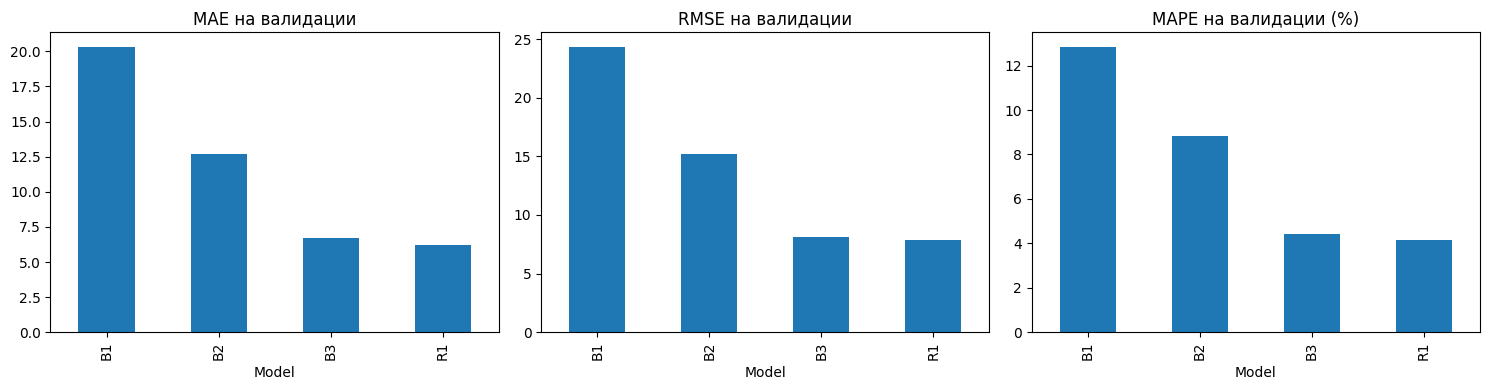

In [60]:
runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('artifacts/runs.csv', index=False)

comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [v['mae'] for v in results.values()],
    'RMSE': [v['rmse'] for v in results.values()],
    'MAPE': [v['mape'] for v in results.values()]
})

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
comparison.plot.bar(x='Model', y='MAE', ax=ax[0], legend=False)
ax[0].set_title('MAE на валидации')
comparison.plot.bar(x='Model', y='RMSE', ax=ax[1], legend=False)
ax[1].set_title('RMSE на валидации')
comparison.plot.bar(x='Model', y='MAPE', ax=ax[2], legend=False)
ax[2].set_title('MAPE на валидации (%)')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

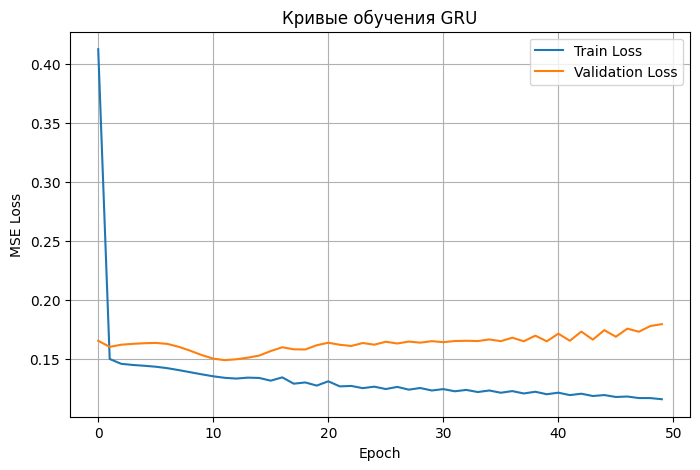

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Кривые обучения GRU')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

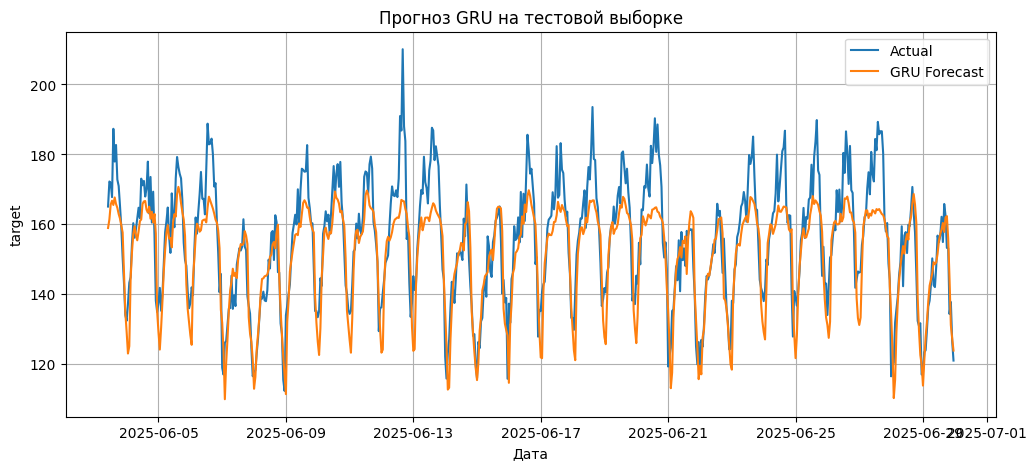

In [62]:
model.eval()
preds_test = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        preds_test.append(output.cpu().numpy())
preds_test = np.concatenate(preds_test).flatten()
# Инвертируем масштабирование
preds_test_inv = target_scaler.inverse_transform(preds_test.reshape(-1, 1)).flatten()
# Истинные значения на тесте (соответствуют тем же индексам)
y_test_actual = test['target'].values[window_size:]

# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(test['date'].values[window_size:], y_test_actual, label='Actual')
plt.plot(test['date'].values[window_size:], preds_test_inv, label='GRU Forecast')
plt.title('Прогноз GRU на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()